In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("retail_store_sales.csv")

In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [ ]:
df.shape

(12575, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [ ]:
#Check the calculation integrity
df["Calculated Total"] = df["Price Per Unit"] * df["Quantity"]
df["Difference"] = df["Total Spent"] - df["Calculated Total"]
(df["Difference"].abs() > 0.01).sum()

np.int64(0)

In [ ]:
df[df.isnull().any(axis=1)].head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Calculated Total,Difference
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,247.5,0.0
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN,NaN,NaN
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True,NaN,NaN
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True,NaN,NaN
14,TXN_2490363,CUST_09,Milk Products,Item_16_MILK,27.5,2.0,55.0,Digital Wallet,Online,2022-05-22,NaN,55.0,0.0
15,TXN_1809665,CUST_14,Beverages,NaN,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN,NaN,NaN
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN,NaN,NaN
19,TXN_4206593,CUST_01,Furniture,NaN,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13,False,NaN,NaN
20,TXN_9939063,CUST_14,Beverages,Item_7_BEV,14.0,9.0,126.0,Digital Wallet,In-store,2024-01-14,NaN,126.0,0.0
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN,NaN,NaN


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Discount Applied,4199
Calculated Total,1213
Difference,1213
Item,1213
Price Per Unit,609
Total Spent,604
Quantity,604
Transaction ID,0
Category,0
Customer ID,0


In [ ]:
#measure the missing-value patterns
missing_pattern = (
    df.isnull()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

missing_pattern

,count
0,7579
1,3783
4,404
5,598
6,211


In [ ]:
df[["Item", "Price Per Unit", "Quantity", "Total Spent"]].isnull().sum(axis=1).value_counts().sort_index()

,count
0,11362
2,609
3,604


In [ ]:
df[["Item", "Price Per Unit", "Quantity", "Total Spent"]].isnull().apply(
    lambda row: tuple(row.index[row]),
    axis=1
).value_counts()

,count
(),11362
"(Item, Price Per Unit)",609
"(Item, Quantity, Total Spent)",604


In [ ]:
df["Discount Applied"].value_counts(dropna=False)

,count
Discount Applied,
True,4219
NaN,4199
False,4157


In [ ]:

df.groupby("Category")["Price Per Unit"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
Category,,,,
Beverages,5.0,41.0,23.314419,1498
Butchers,5.0,41.0,25.114869,1493
Computers and electric accessories,5.0,41.0,23.154263,1478
Electric household essentials,5.0,41.0,24.385913,1512
Food,5.0,41.0,23.093563,1507
Furniture,5.0,41.0,23.363696,1526
Milk Products,5.0,41.0,21.417781,1496
Patisserie,5.0,41.0,23.066964,1456


In [ ]:
df.groupby("Category")["Item"].nunique().sort_values(ascending=False)

,Item
Category,
Beverages,25
Butchers,25
Computers and electric accessories,25
Electric household essentials,25
Food,25
Furniture,25
Milk Products,25
Patisserie,25


In [ ]:
df.groupby("Discount Applied", dropna=False)["Total Spent"].agg(["count", "mean", "median"])

,count,mean,median
Discount Applied,,,
False,3964,129.953330,109.5
True,4019,130.491043,109.5
NaN,3988,128.508651,105.0


In [ ]:
df.fillna(0)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Calculated Total,Difference
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,185.0,0.0
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,261.0,0.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,43.0,0.0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0,247.5,0.0
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,87.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,0,152.0,0.0
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,58.5,0.0
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,0,140.0,0.0
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,84.0,0.0


In [ ]:
#make copy beafore change anything
clean_df = df.copy()

In [ ]:
clean_df = clean_df.drop(columns=["Calculated Total", "Difference"])

In [ ]:
clean_df.shape

(12575, 11)

In [ ]:
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
recoverable_price = (
    clean_df["Price Per Unit"].isna()
    & clean_df["Quantity"].notna()
    & clean_df["Total Spent"].notna()
)

recoverable_price.sum()

np.int64(609)

In [ ]:
clean_df.loc[recoverable_price, "Quantity"].min()

1.0

In [ ]:
clean_df.loc[recoverable_price, "Price Per Unit"] = (
    clean_df.loc[recoverable_price, "Total Spent"]
    / clean_df.loc[recoverable_price, "Quantity"]
)

In [ ]:
clean_df["Price Per Unit"].isna().sum()

np.int64(0)

In [ ]:
(
    clean_df["Total Spent"]
    - clean_df["Price Per Unit"] * clean_df["Quantity"]
).abs().gt(0.01).sum()

np.int64(0)

In [ ]:
incomplete_transactions = clean_df[
    clean_df["Quantity"].isna() & clean_df["Total Spent"].isna()
]

incomplete_transactions.shape

(604, 11)

In [ ]:
incomplete_transactions[[
    "Transaction ID",
    "Category",
    "Price Per Unit",
    "Quantity",
    "Total Spent",
    "Payment Method",
    "Location",
    "Transaction Date"
]].head(10)

,Transaction ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
7,TXN_1372952,Furniture,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02
15,TXN_1809665,Beverages,24.5,NaN,NaN,Credit Card,In-store,2022-05-11
19,TXN_4206593,Furniture,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13
25,TXN_3481599,Furniture,39.5,NaN,NaN,Cash,Online,2022-09-08
34,TXN_1621497,Patisserie,23.0,NaN,NaN,Cash,In-store,2023-02-18
83,TXN_4532214,Patisserie,15.5,NaN,NaN,Credit Card,In-store,2024-03-25
112,TXN_5419965,Computers and electric accessories,20.0,NaN,NaN,Digital Wallet,Online,2024-01-16
114,TXN_8210621,Beverages,39.5,NaN,NaN,Digital Wallet,Online,2024-01-03
118,TXN_8586300,Computers and electric accessories,27.5,NaN,NaN,Credit Card,Online,2022-02-08
138,TXN_1154680,Furniture,35.0,NaN,NaN,Credit Card,Online,2022-12-18


In [ ]:
incomplete_transactions["Price Per Unit"].describe()

,Price Per Unit
count,604.000000
mean,23.536424
std,10.891040
min,5.000000
25%,14.000000
50%,23.000000
75%,33.500000
max,41.000000


We leave the 604 rows as it bcz there is such columns missing which could be fullfill by averags, that led to incorrect future reports that's we let them

In [ ]:
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,0
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


let's investigate whether the dataset contains a pattern between price, category, and discount that could help us understand the missing values.


In [ ]:
clean_df.groupby("Discount Applied", dropna=False)["Price Per Unit"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Discount Applied,,,,,
False,4157,23.405942,23.0,5.0,41.0
True,4219,23.463617,23.0,5.0,41.0
NaN,4199,23.238271,23.0,5.0,41.0


In [ ]:
clean_df.groupby(["Category", "Discount Applied"], dropna=False).size().unstack(fill_value=0)

Discount Applied,False,True,NaN
Category,,,
Beverages,495,521,551
Butchers,514,543,511
Computers and electric accessories,546,535,477
Electric household essentials,528,522,541
Food,547,508,533
Furniture,486,535,570
Milk Products,549,540,495
Patisserie,492,515,521


In [ ]:
clean_df["Discount Applied"] = clean_df["Discount Applied"].fillna("Unknown")

In [ ]:
clean_df["Discount Applied"].value_counts()

,count
Discount Applied,
True,4219
Unknown,4199
False,4157


In [ ]:
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,0
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


**Outlier Detection**

In [ ]:
#interquartile method using
#Price Per Unit
Q1 = clean_df["Price Per Unit"].quantile(0.25)
Q3 = clean_df["Price Per Unit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 14.0
Q3: 33.5
IQR: 19.5
Lower Bound: -15.25
Upper Bound: 62.75


Outlier analysis of Price Per Unit using the IQR method identified no outliers. Therefore, no outlier treatment was required for

In [ ]:
#Analyze Quantity
Q1 = clean_df["Quantity"].quantile(0.25)
Q3 = clean_df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.0
Q3: 8.0
IQR: 5.0
Lower Bound: -4.5
Upper Bound: 15.5


In [ ]:
quantity_outliers = clean_df[
    (clean_df["Quantity"] < lower_bound) |
    (clean_df["Quantity"] > upper_bound)
]

print("Number of Quantity outliers:", len(quantity_outliers))

Number of Quantity outliers: 0


In [ ]:
#Total Spent
Q1 = clean_df["Total Spent"].quantile(0.25)
Q3 = clean_df["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 51.0
Q3: 192.0
IQR: 141.0
Lower Bound: -160.5
Upper Bound: 403.5


In [ ]:
total_outliers = clean_df[
    (clean_df["Total Spent"] < lower_bound) |
    (clean_df["Total Spent"] > upper_bound)
]

print("Number of Total Spent outliers:", len(total_outliers))

Number of Total Spent outliers: 60


In [ ]:
total_outliers[[
    "Transaction ID",
    "Category",
    "Item",
    "Price Per Unit",
    "Quantity",
    "Total Spent",
    "Payment Method",
    "Location",
    "Transaction Date"
]].sort_values("Total Spent", ascending=False).head(20)

,Transaction ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
27,TXN_1599706,Furniture,Item_25_FUR,41.0,10.0,410.0,Credit Card,In-store,2024-03-24
133,TXN_2953434,Furniture,Item_25_FUR,41.0,10.0,410.0,Credit Card,In-store,2023-08-10
339,TXN_4374445,Food,Item_25_FOOD,41.0,10.0,410.0,Digital Wallet,Online,2024-10-17
869,TXN_1814138,Beverages,Item_25_BEV,41.0,10.0,410.0,Credit Card,In-store,2024-11-16
1060,TXN_3710081,Furniture,Item_25_FUR,41.0,10.0,410.0,Digital Wallet,In-store,2023-08-12
1088,TXN_1273334,Beverages,Item_25_BEV,41.0,10.0,410.0,Digital Wallet,In-store,2022-11-04
1468,TXN_1938135,Butchers,Item_25_BUT,41.0,10.0,410.0,Digital Wallet,In-store,2023-12-20
1505,TXN_8520397,Electric household essentials,Item_25_EHE,41.0,10.0,410.0,Credit Card,Online,2024-03-27
1568,TXN_8048041,Butchers,Item_25_BUT,41.0,10.0,410.0,Credit Card,In-store,2023-12-25
1950,TXN_1860120,Furniture,Item_25_FUR,41.0,10.0,410.0,Digital Wallet,Online,2022-01-19


In [ ]:
total_outliers["Total Spent"].describe()

,Total Spent
count,60.0
mean,410.0
std,0.0
min,410.0
25%,410.0
50%,410.0
75%,410.0
max,410.0


IQR analysis identified 60 outliers in Total Spent. Upon investigation, all identified records represented valid transactions where Price Per Unit × Quantity = Total Spent (41 × 10 = 410). Therefore, these observations were retained rather than removed.

**DATA Visualization**

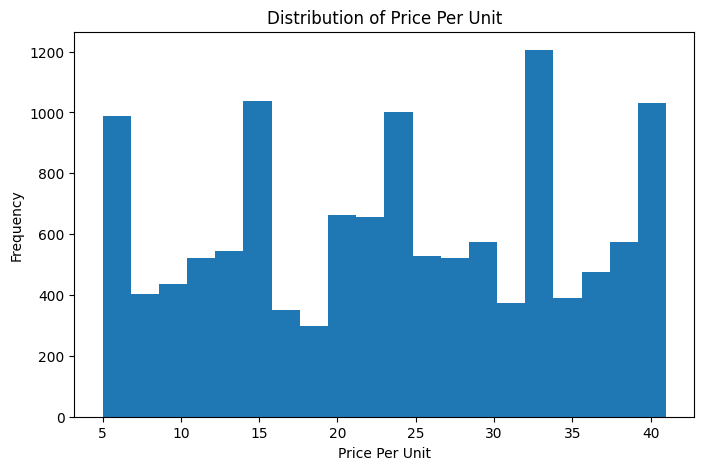

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(clean_df["Price Per Unit"], bins=20)
plt.title("Distribution of Price Per Unit")
plt.xlabel("Price Per Unit")
plt.ylabel("Frequency")
plt.show()

The histogram shows that prices are distributed across the range of 5 to 41, with several noticeable frequency peaks. No extreme values were observed, consistent with the IQR analysis, which identified no outliers.

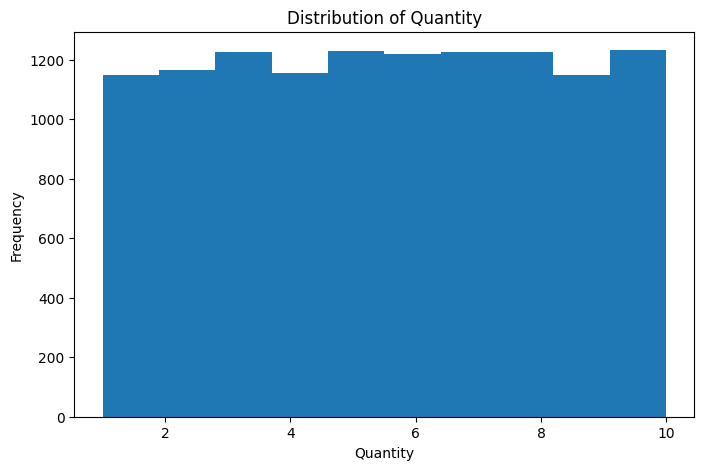

In [ ]:
#Quantity distribution

plt.figure(figsize=(8, 5))
plt.hist(clean_df["Quantity"].dropna(), bins=10)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

The histogram shows that transaction quantities range from 1 to 10 and are relatively evenly distributed. No extreme values were observed, which is consistent with the IQR analysis that identified no quantity outliers.

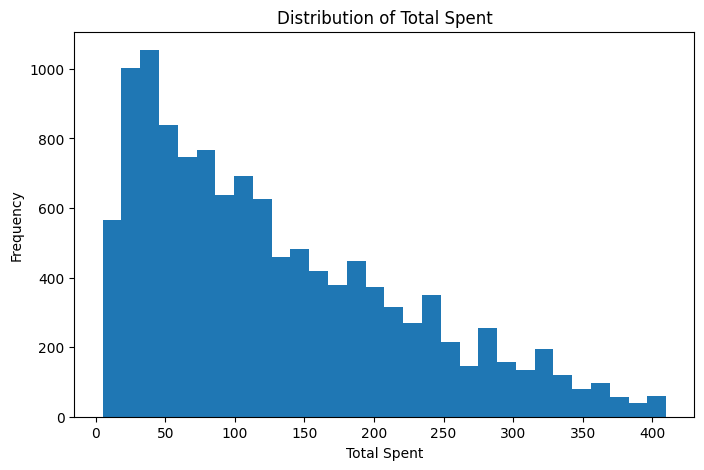

In [ ]:
#Total Spent distribution


plt.figure(figsize=(8, 5))
plt.hist(clean_df["Total Spent"].dropna(), bins=30)
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

The distribution is right-skewed, with most transactions having relatively low total spending and fewer transactions at higher spending levels. The maximum value of 410 was identified as an IQR outlier; however, investigation confirmed that these observations are valid transactions because the total equals the product of price per unit and quantity. Therefore, the observations were retained.

In [ ]:
clean_df.dtypes


,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
#Converting Transaction Date/
clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce"
)

In [ ]:
clean_df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]


In [ ]:
clean_df["Transaction Date"].isna().sum()

np.int64(0)

In [ ]:
#investigate missing Item


item_price_check = (
    clean_df.dropna(subset=["Item"])
    .groupby(["Category", "Price Per Unit"])["Item"]
    .nunique()
)


print(item_price_check.value_counts())

Item
1    200
Name: count, dtype: int64


In [ ]:
#Create the Category + Price → Item mapping


item_mapping = (
    clean_df.dropna(subset=["Item"])
    .drop_duplicates(["Category", "Price Per Unit"])
    .set_index(["Category", "Price Per Unit"])["Item"]
)


print(item_mapping.head(20))

Category                       Price Per Unit
Patisserie                     18.5               Item_10_PAT
Milk Products                  29.0              Item_17_MILK
Butchers                       21.5               Item_12_BUT
Beverages                      27.5               Item_16_BEV
Food                           12.5               Item_6_FOOD
                               5.0                Item_1_FOOD
Furniture                      27.5               Item_16_FUR
Butchers                       36.5               Item_22_BUT
                               8.0                 Item_3_BUT
Food                           6.5                Item_2_FOOD
Patisserie                     39.5               Item_24_PAT
Milk Products                  27.5              Item_16_MILK
Patisserie                     29.0               Item_17_PAT
Electric household essentials  23.0               Item_13_EHE
Beverages                      14.0                Item_7_BEV
Electric household essen

In [ ]:
item_filled = clean_df.set_index(
    ["Category", "Price Per Unit"]
).index.map(item_mapping)

clean_df["Item"] = clean_df["Item"].fillna(
    pd.Series(item_filled, index=clean_df.index)
)

In [ ]:
clean_df["Item"].isnull().sum()

np.int64(0)

In [ ]:
clean_df.shape

(12575, 11)

In [ ]:
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


we've successfully recovered Item, we now have another useful variable. We can investigate whether each Item has a consistent quantity pattern.

In [ ]:
#nvestigate Quantity by Item


quantity_by_item = clean_df.groupby("Item")["Quantity"].agg(
    ["count", "mean", "median", "min", "max"]
)


quantity_by_item.head(20)

,count,mean,median,min,max
Item,,,,,
Item_10_BEV,23,6.782609,8.0,1.0,10.0
Item_10_BUT,16,5.875000,6.0,1.0,10.0
Item_10_CEA,77,5.428571,5.0,1.0,10.0
Item_10_EHE,43,5.000000,5.0,1.0,10.0
Item_10_FOOD,57,5.157895,5.0,1.0,10.0
Item_10_FUR,32,5.875000,6.0,1.0,10.0
Item_10_MILK,9,6.000000,5.0,2.0,10.0
Item_10_PAT,31,4.838710,4.0,1.0,10.0
Item_11_BEV,65,5.569231,5.0,1.0,10.0


In [ ]:
clean_df.groupby("Item")["Quantity"].nunique().describe()

,Quantity
count,200.000000
mean,9.530000
std,1.255781
min,3.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [ ]:
clean_df["Quantity"].describe()


,Quantity
count,11971.000000
mean,5.536380
std,2.857883
min,1.000000
25%,3.000000
50%,6.000000
75%,8.000000
max,10.000000


In [ ]:
clean_df["Quantity"].value_counts().sort_index()

,count
Quantity,
1.0,1147
2.0,1164
3.0,1224
4.0,1155
5.0,1228
6.0,1220
7.0,1227
8.0,1226
9.0,1148


the mean is 5.54 and median is 6.

So I want to correct one thing from my previous message: we should NOT fill the 604 missing quantities with 10. The full dataset shows that quantities 1–10 occur fairly evenly.

Our approach

Since we don't know the original quantities for those 604 records, the safest simple systematic treatment for this internship task is median imputation. **bold text**

In [ ]:
quantity_median = clean_df["Quantity"].median()
print(quantity_median)

6.0


In [ ]:
clean_df["Quantity"] = clean_df["Quantity"].fillna(quantity_median)

In [ ]:
clean_df["Quantity"].isnull().sum()

np.int64(0)

In [ ]:
clean_df["Quantity"].value_counts().sort_index()

,count
Quantity,
1.0,1147
2.0,1164
3.0,1224
4.0,1155
5.0,1228
6.0,1824
7.0,1227
8.0,1226
9.0,1148


In [ ]:
missing_total = clean_df["Total Spent"].isnull()

clean_df.loc[missing_total, "Total Spent"] = (
    clean_df.loc[missing_total, "Price Per Unit"] *
    clean_df.loc[missing_total, "Quantity"]
)

In [ ]:
clean_df["Total Spent"].isnull().sum()

np.int64(0)

In [ ]:
clean_df["Calculated Total"] = (
    clean_df["Price Per Unit"] * clean_df["Quantity"]
)

difference = (
    clean_df["Total Spent"] - clean_df["Calculated Total"]
).abs()

difference.max()

0.0

***descriptive distributions ***

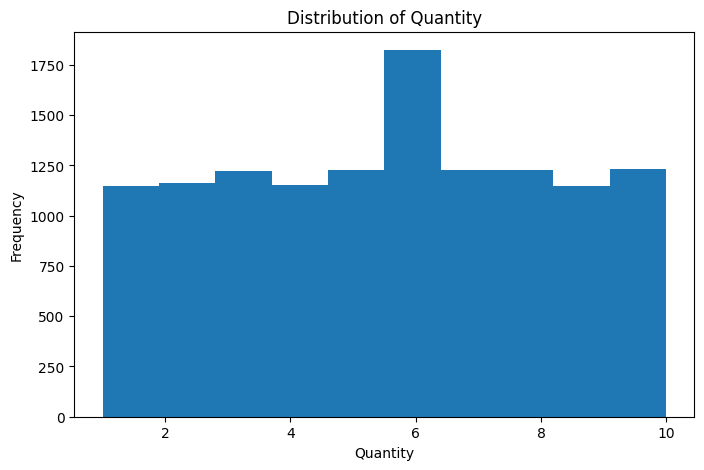

In [ ]:
import matplotlib.pyplot as plt

# Quantity distribution
plt.figure(figsize=(8,5))
plt.hist(clean_df["Quantity"], bins=10)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()

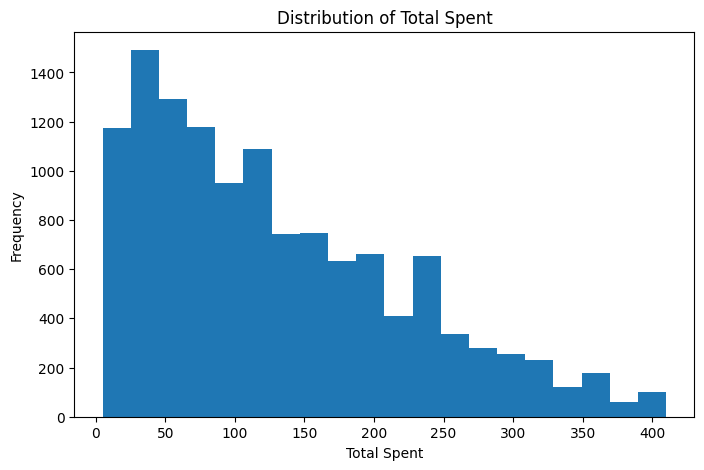

In [ ]:
# Total Spent distribution
plt.figure(figsize=(8,5))
plt.hist(clean_df["Total Spent"], bins=20)
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.title("Distribution of Total Spent")
plt.show()

Quantity values range from 1 to 10 and are generally distributed across the range. A higher frequency at quantity 6 is partly due to median imputation of 604 missing quantity values."

Total Spent is right-skewed, with most transactions concentrated at lower spending levels. A smaller number of transactions have substantially higher spending, with values extending to 410. The extreme value of 410 is consistent with the maximum price and quantity combination and was therefore retained

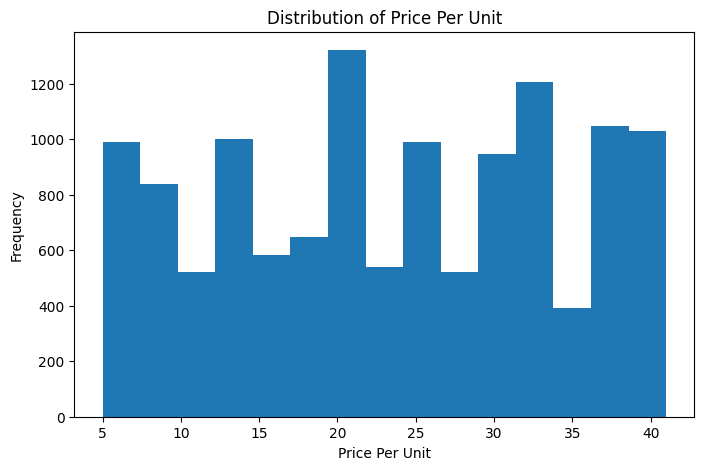

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(clean_df["Price Per Unit"], bins=15)

plt.xlabel("Price Per Unit")
plt.ylabel("Frequency")
plt.title("Distribution of Price Per Unit")

plt.show()

In [ ]:
#Category analysis
category_summary = clean_df.groupby("Category").agg(
    Transactions=("Transaction ID", "count"),
    Total_Sales=("Total Spent", "sum"),
    Average_Spent=("Total Spent", "mean")
).sort_values("Total_Sales", ascending=False)

category_summary

,Transactions,Total_Sales,Average_Spent
Category,,,
Butchers,1568,218153.0,139.128189
Electric household essentials,1591,215297.5,135.322124
Beverages,1567,206854.5,132.006701
Furniture,1591,205390.0,129.094909
Food,1588,205225.0,129.234887
Computers and electric accessories,1558,202023.5,129.668485
Patisserie,1528,194531.5,127.311191
Milk Products,1584,189892.0,119.881313


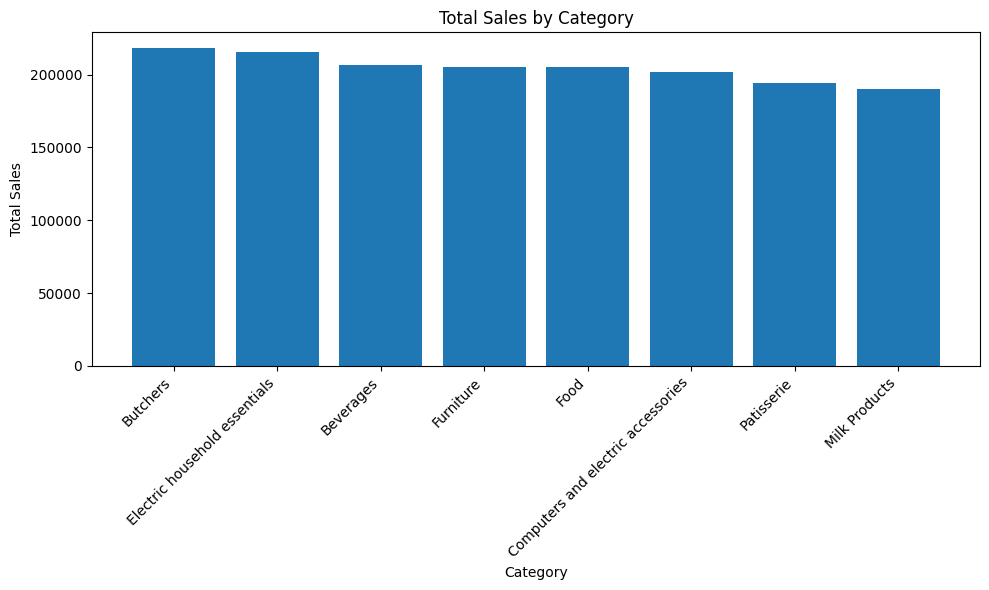

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    category_summary.index,
    category_summary["Total_Sales"]
)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
#Final missing-value check and duplicates etc etc check
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
clean_df.duplicated().sum()

np.int64(0)

In [ ]:
clean_df.shape

(12575, 12)

In [ ]:
clean_df = clean_df.drop(columns=["Calculated Total"])

In [ ]:
clean_df.shape

(12575, 11)

In [ ]:
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
clean_df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]
